# 02c · Segmentation of samples with diffuse signal

For samples without inclusion bodies, whole cells are segmented from the
fluorescence intensity image with Cellpose-SAM. There is no IB mask; the cell
mask is what the later notebooks treat as cytosol.

Masks are written to `masks_auto/<sample>_cell_masks/`, with one overview
`.png` per sample.

In [1]:
import os

import matplotlib.pyplot as plt
from skimage import io

from cellpose import models

import flim_fret_data_processing.config as config
from flim_fret_data_processing.helpers import index_samples, overlay_labels, save_labels, save_overview

## Inputs

In [2]:
raw_dir       = config.RAW_DIR          # only to find the session of each sample
intensity_dir = config.INTENSITY_DIR    # <session>/<sample>_export
output_dir    = config.MASKS_AUTO_DIR

# Sample folders to segment.
samples = ['20', 'GS1', 'GS2', 'GS3', 'GS4', 'R1N-3', 'Turq']

use_gpu = __import__("torch").cuda.is_available()

## Segment

In [4]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"Sparse invariant checks are implicitly disabled.*",
    category=UserWarning,
)

sample_index = index_samples(raw_dir)
model = models.CellposeModel(gpu=use_gpu)

overview = {}   # sample -> rows of the overview figure

for sample in samples:
    export_dir = os.path.join(intensity_dir, sample_index[sample]['session'], sample + '_export')

    for f in sorted(f for f in os.listdir(export_dir) if f.endswith('.tif')):
        base = f[:-len('.tif')]
        image = io.imread(os.path.join(export_dir, f), as_gray=True)

        cell_labels, _, _ = model.eval(image, diameter=None)
        print(f"{sample}/{base}: {cell_labels.max()} cell(s)")

        save_labels(os.path.join(output_dir, sample + '_cell_masks'),
                    base + '_cell_labels.tif', cell_labels)
        overview.setdefault(sample, []).append(
            (base, overlay_labels(image, cell_labels, alpha=0.5)))

for sample, rows in overview.items():
    save_overview(os.path.join(output_dir, sample + '_overview.png'), sample, rows,
                  ("Cell labels",))

20/MultiHarp150_2025-07-30_15-19-06.438: 5 cell(s)
20/MultiHarp150_2025-07-30_15-20-43.064: 2 cell(s)
20/MultiHarp150_2025-07-30_15-22-29.776: 2 cell(s)
20/MultiHarp150_2025-07-30_15-24-32.874: 4 cell(s)
20/MultiHarp150_2025-07-30_15-28-13.524: 2 cell(s)
GS1/MultiHarp150_2025-04-09_16-16-04: 1 cell(s)
GS1/MultiHarp150_2025-04-09_16-17-08: 1 cell(s)
GS1/MultiHarp150_2025-04-09_16-17-44: 1 cell(s)
GS1/MultiHarp150_2025-04-09_16-18-31: 1 cell(s)
GS1/MultiHarp150_2025-04-09_16-19-08: 1 cell(s)
GS1/MultiHarp150_2025-04-09_16-21-03: 2 cell(s)
GS1/MultiHarp150_2025-04-09_16-21-42: 1 cell(s)
GS1/MultiHarp150_2025-04-09_16-22-19: 1 cell(s)
GS1/MultiHarp150_2025-04-09_16-23-04: 1 cell(s)
GS1/MultiHarp150_2025-04-09_16-23-47: 1 cell(s)
GS2/MultiHarp150_2025-04-09_16-28-15: 4 cell(s)
GS2/MultiHarp150_2025-04-09_16-28-53: 1 cell(s)
GS3/MultiHarp150_2025-04-09_16-34-27: 5 cell(s)
GS3/MultiHarp150_2025-04-09_16-34-59: 2 cell(s)
GS3/MultiHarp150_2025-04-09_16-35-52: 7 cell(s)
GS3/MultiHarp150_2025-04-

## Example

The overlays of the last sample; all samples are in the saved overviews.

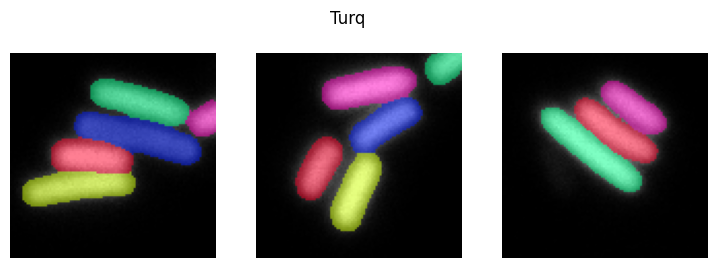

In [5]:
if overview:
    sample, rows = list(overview.items())[-1]
    fig, axes = plt.subplots(1, len(rows), figsize=(3 * len(rows), 3), squeeze=False)
    for ax, (base, overlay) in zip(axes[0], rows):
        ax.imshow(overlay)
        ax.set_axis_off()
    fig.suptitle(sample)
    plt.show()